In [2]:
import pandas as pd
df = pd.read_csv('data/hour.csv')
print(df.shape)
print(df.columns.tolist())

(17379, 17)
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


In [3]:
print(df.columns.tolist())
print(df.dtypes)
print(df.isnull().sum())

['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Define columns
drop_cols = ['instant', 'dteday', 'casual', 'registered', 'temp']
features  = ['atemp', 'hum', 'windspeed', 'hr', 'season', 'workingday']
target    = 'cnt'

# Drop unnecessary columns
df = df.drop(columns=drop_cols)

# Describe features + target
df[features + [target]].describe()
print(df[features + [target]].describe().round(2))

          atemp       hum  windspeed        hr    season  workingday       cnt
count  17379.00  17379.00   17379.00  17379.00  17379.00    17379.00  17379.00
mean       0.48      0.63       0.19     11.55      2.50        0.68    189.46
std        0.17      0.19       0.12      6.91      1.11        0.47    181.39
min        0.00      0.00       0.00      0.00      1.00        0.00      1.00
25%        0.33      0.48       0.10      6.00      2.00        0.00     40.00
50%        0.48      0.63       0.19     12.00      3.00        1.00    142.00
75%        0.62      0.78       0.25     18.00      3.00        1.00    281.00
max        1.00      1.00       0.85     23.00      4.00        1.00    977.00


### Target Distribution

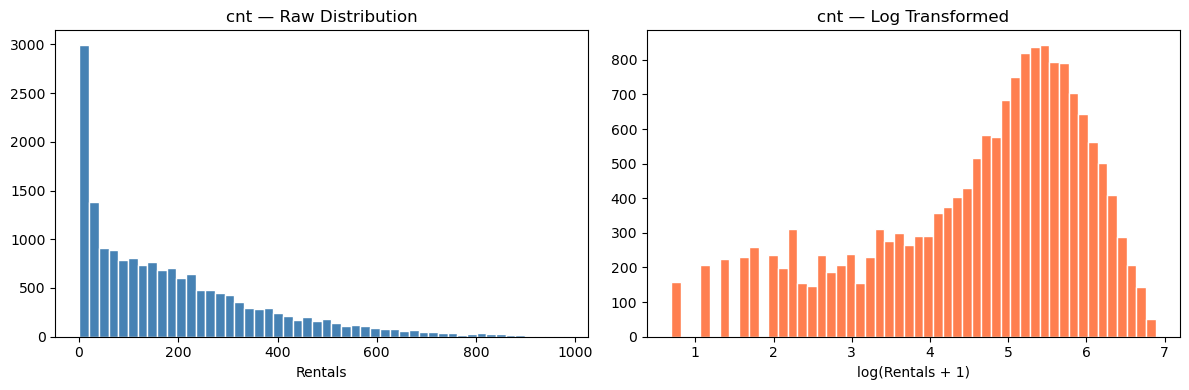

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['cnt'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('cnt — Raw Distribution')
axes[0].set_xlabel('Rentals')

axes[1].hist(np.log1p(df['cnt']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('cnt — Log Transformed')
axes[1].set_xlabel('log(Rentals + 1)')

plt.tight_layout()
plt.savefig('results/cnt_distribution.png', dpi=150)
plt.show()

### atemp vs cnt

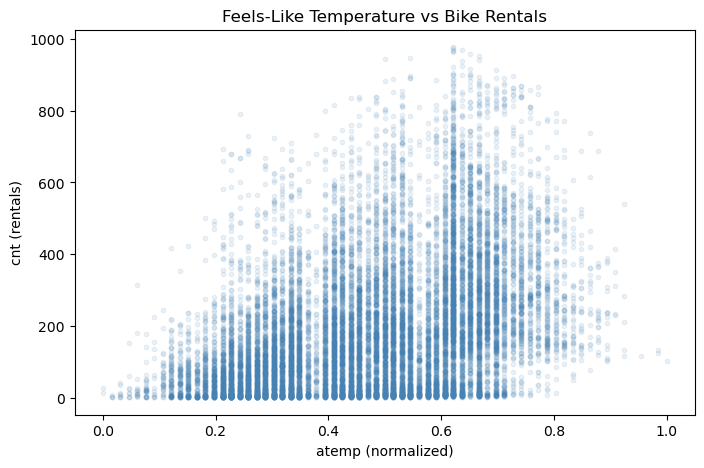

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(df['atemp'], df['cnt'], alpha=0.1, color='steelblue', s=10)
plt.title('Feels-Like Temperature vs Bike Rentals')
plt.xlabel('atemp (normalized)')
plt.ylabel('cnt (rentals)')
plt.savefig('results/temp_vs_rentals_scatter.png', dpi=150)
plt.show()

### Hourly patterns

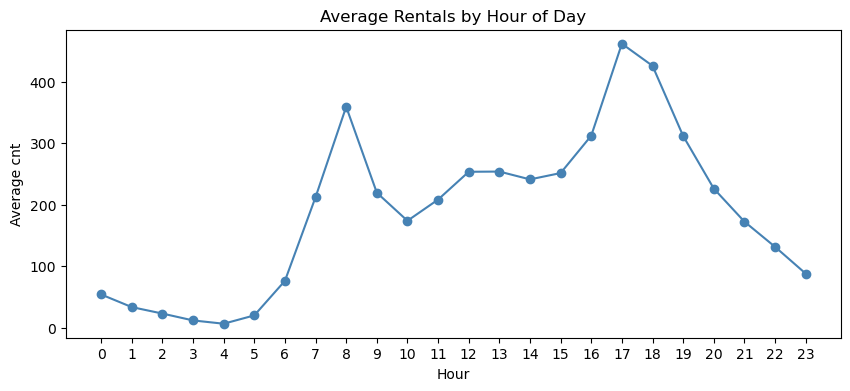

In [8]:
hourly = df.groupby('hr')['cnt'].mean()

plt.figure(figsize=(10, 4))
plt.plot(hourly.index, hourly.values, marker='o', color='steelblue')
plt.title('Average Rentals by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average cnt')
plt.xticks(range(0, 24))
plt.savefig('results/hourly_patterns.png', dpi=150)
plt.show()

### Seasonal breakdown

/var/folders/k8/ncpzqds97lb86kwyp4d1byq00000gn/T/ipykernel_3038/2662739203.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season_label', y='cnt',


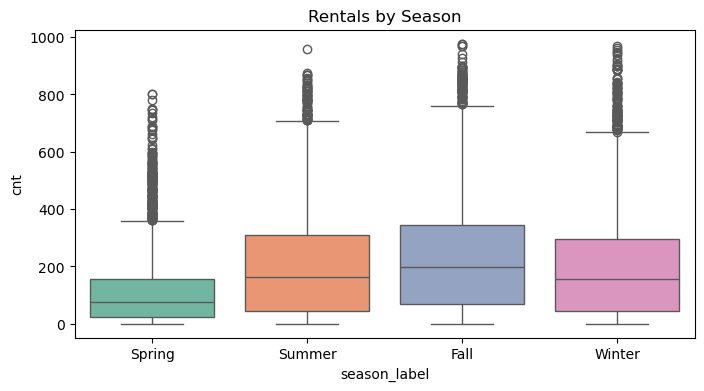

In [9]:
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
df['season_label'] = df['season'].map(season_map)

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='season_label', y='cnt',
            order=['Spring','Summer','Fall','Winter'],
            palette='Set2')
plt.title('Rentals by Season')
plt.savefig('results/seasonal_breakdown.png', dpi=150)
plt.show()

### Correlation heatmap

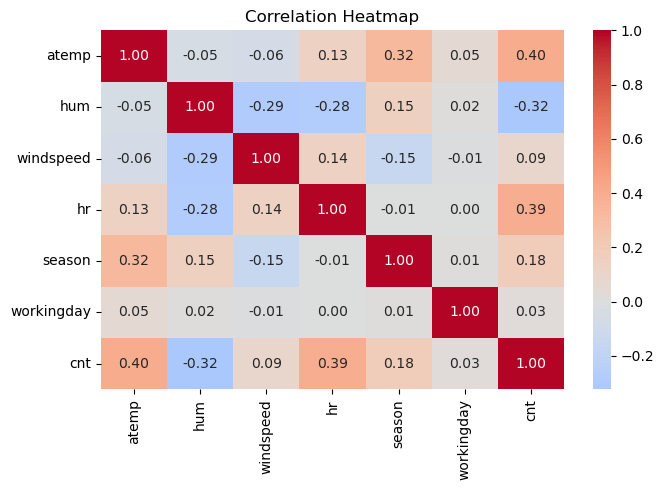

In [10]:
plt.figure(figsize=(7, 5))
corr = df[features + [target]].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('results/correlation_heatmap.png', dpi=150)
plt.show()

### Key Findings

1. `cnt` is right-skewed — peak hours dominate, log transform helps normality
2. `atemp` vs `cnt` shows a clear **inverted-U curve** — linear regression will underfit this
3. Two clear rush-hour peaks at 8am and 5-6pm — `hr` is a strong feature
4. Fall has highest rentals, Spring lowest
5. `atemp` has the highest positive correlation with `cnt` among continuous features
6. This non-linearity in `atemp` is exactly why we need polynomial regression